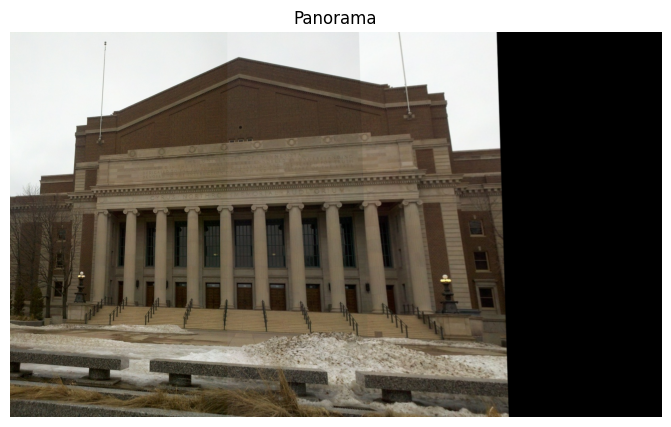

In [ ]:
#Image Stitching / Panorama Creation
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread("./Images/mall1.jpg")
img2 = cv2.imread("./Images/mall2.jpg")
img3 = cv2.imread("./Images/mall3.jpg")

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

keyptr1, desc1 = sift.detectAndCompute(gray1, None)
keyptr2, desc2 = sift.detectAndCompute(gray2, None)
keyptr3, desc3 = sift.detectAndCompute(gray3, None)

FLANN = 1
index_p = dict(algorithm=FLANN, trees=5)
search_p = dict(checks=5000)

flann = cv2.FlannBasedMatcher(index_p, search_p)
matches1_2 = flann.knnMatch(desc1, desc2, k=2)

good_matches1_2 = []
for m, n in matches1_2:
    if m.distance < 2 * n.distance:
        good_matches1_2.append(m)

matches2_3 = flann.knnMatch(desc2, desc3, k=2)

good_matches2_3 = []
for m, n in matches2_3:
    if m.distance < 2 * n.distance:
        good_matches2_3.append(m)

src1 = np.float32([keyptr1[m.queryIdx].pt for m in good_matches1_2]).reshape(-1, 1, 2)
dst1 = np.float32([keyptr2[m.trainIdx].pt for m in good_matches1_2]).reshape(-1, 1, 2)

src2 = np.float32([keyptr2[m.queryIdx].pt for m in good_matches2_3]).reshape(-1, 1, 2)
dst2 = np.float32([keyptr3[m.trainIdx].pt for m in good_matches2_3]).reshape(-1, 1, 2)

H1, _ = cv2.findHomography(dst1, src1, cv2.RANSAC, 10.0)
H2, _ = cv2.findHomography(dst2, src2, cv2.RANSAC, 10.0)

result1 = cv2.warpPerspective(img3_rgb, H2, (img3_rgb.shape[1] + img2_rgb.shape[1], img3_rgb.shape[0]))
result1[:img2_rgb.shape[0], 0:img2_rgb.shape[1]] = img2_rgb

result2 = cv2.warpPerspective(result1, H1, (result1.shape[1] + img1_rgb.shape[1], result1.shape[0]))
result2[0:img1_rgb.shape[0], 0:img1_rgb.shape[1]] = img1_rgb

plt.figure(figsize=(10, 5))
plt.imshow(result2)
plt.title('Panorama')
plt.axis('off')
plt.show()
